# Exploratory Data Analysis on Retail Sales Data


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("Dataset/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.shape           # 1000 rows , 8 columns

(1000, 9)

## Data Cleaning

In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

The dataset do not contains any missing values,
which means the dataset quality is fairly good
for analysis.

In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


The average sales value indicates that most
transactions are moderate, while some high-value
transactions contribute significantly to overall revenue.

In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [10]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


The customer base mainly consists of middle-aged
individuals, indicating strong purchasing activity
among adult consumers.

In [11]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

Gender Distribution

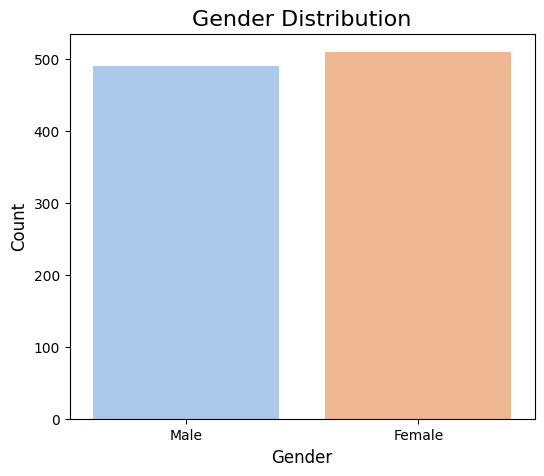

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    hue='Gender',
    data=df,
    palette='pastel',
    legend=False
)

plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.savefig(
    "Charts/gender_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The customer distribution between male and female
customers appears relatively balanced, suggesting
that the business attracts diverse customer groups.

In [13]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

Product Category Sales Analysis

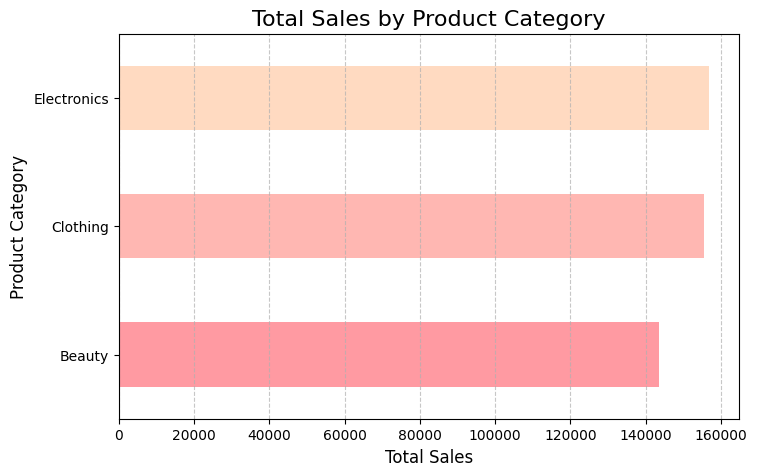

In [14]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values()

plt.figure(figsize=(8,5))

category_sales.plot(
    kind='barh',
    color=['#FF9AA2', '#FFB7B2', '#FFDAC1']
)

plt.title("Total Sales by Product Category", fontsize=16)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Category", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig(
    "Charts/category_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Certain product categories contribute significantly
more revenue compared to others, indicating higher
customer demand in those segments.

In [15]:
df.groupby('Product Category')['Quantity'].sum()

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

Some product categories show consistently higher
purchase quantities, reflecting strong customer interest
and frequent buying behavior.

Age Analysis

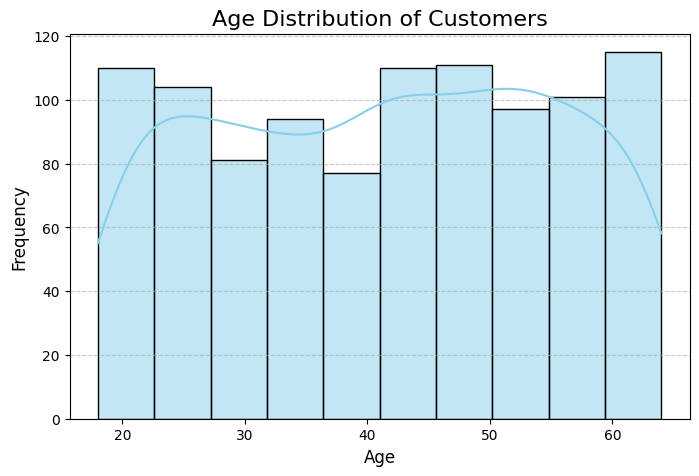

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=10,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

plt.title("Age Distribution of Customers", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig(
    "Charts/age_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Most customers fall within the adult age group,
which may represent the primary target audience
for the business.

In [17]:
df['Month'] = df['Date'].dt.month

In [18]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

Monthly Sales Trend

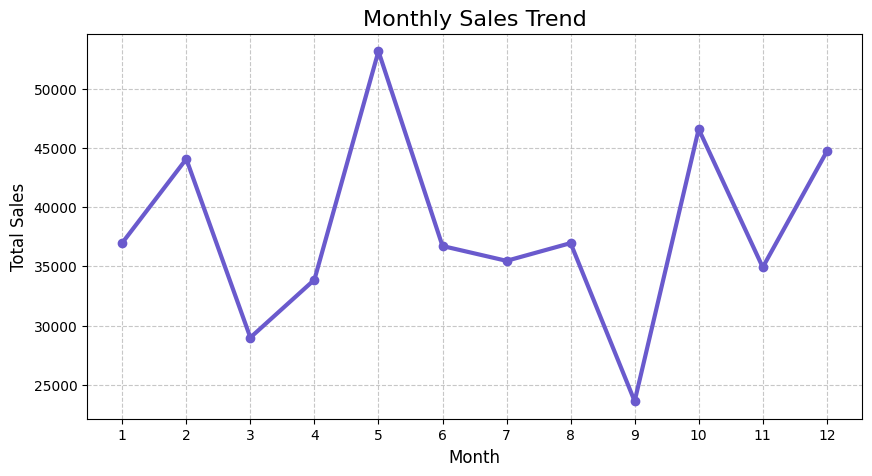

In [19]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='#6A5ACD'
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(range(1,13))

plt.grid(
    linestyle='--',
    alpha=0.7
)

plt.savefig(
    "Charts/monthly_sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Sales performance varied across different months,
indicating possible seasonal trends and changing
customer purchasing patterns.

In [20]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

top_customers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

Top Spending Customers

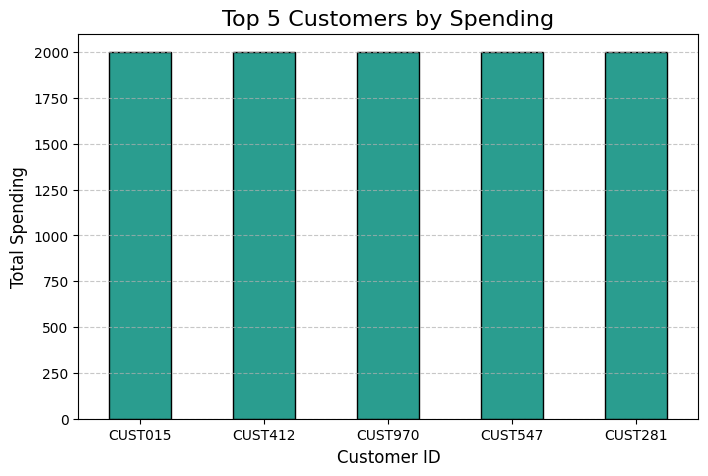

In [21]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))

top_customers.plot(
    kind='bar',
    color='#2A9D8F',
    edgecolor='black'
)

plt.title("Top 5 Customers by Spending", fontsize=16)
plt.xlabel("Customer ID", fontsize=12)
plt.ylabel("Total Spending", fontsize=12)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.savefig(
    "Charts/top_customers.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

A small number of customers contribute a significant
portion of total revenue, highlighting the importance
of customer retention strategies.

Correlation Heatmap

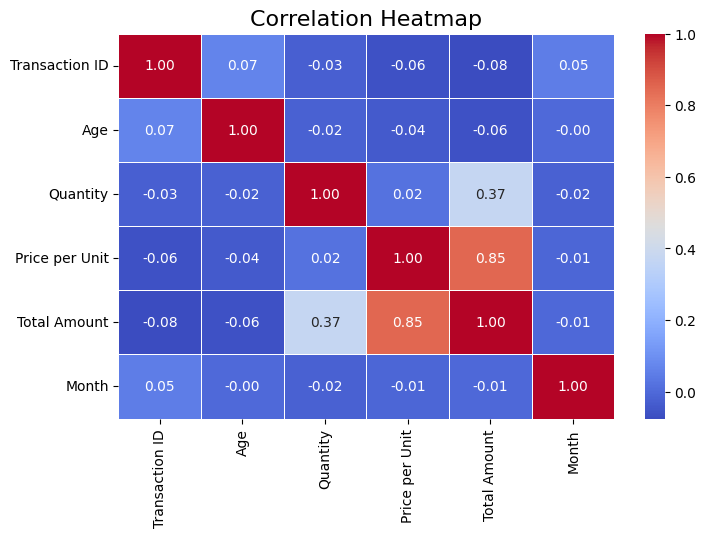

In [22]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=16)

plt.savefig(
    "Charts/heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Strong relationships can be observed between
quantity purchased and total transaction amount,
which is expected in retail purchasing behavior.

## Recommendations

1. Focus marketing efforts on high-performing product categories.

2. Introduce loyalty programs for high-value customers.

3. Analyze seasonal trends to improve inventory planning.

4. Target adult customers with personalized promotions.

## Conclusion

This project explored retail sales data using
exploratory data analysis techniques. The analysis
revealed important insights related to customer
behavior, product performance, and sales trends,
which can support better business decisions.